# Part 1 -- Data Cleaning & Feature Engineering

**PRECOG Quant Trading Task**

This notebook is the first stage of a 4-part pipeline:

1. **Part 1 (this notebook)** -- load the raw OHLCV data for 100 anonymized
   assets, validate/clean it, and engineer a set of causal technical
   features.
2. **Part 2** -- walk-forward train an ensemble model (Ridge + LightGBM +
   Logistic) to score each asset's expected 5-day forward return, evaluated
   via the Information Coefficient (IC).
3. **Part 3** -- backtest a long/short decile portfolio built from those
   scores, with transaction costs, against an equal-weight benchmark.
4. **Part 4** -- a statistical-arbitrage (pairs trading) overlay, with pairs
   selected only on train+validation data and evaluated out-of-sample.

## A note on look-ahead bias

The central design constraint across this whole project is: **at every
point where a number is computed, ask "would this number have been knowable
on this date, using only data up to this date?"** Concretely:

- All technical indicators below are built from rolling windows, EWMs, or
  `.shift()` -- never from a global / full-sample statistic.
- Any cross-sectional statistic (e.g. a feature's rank across the 100
  tickers) is computed **per date**, never pooling across dates.
- The train / validation / test date ranges defined in `src/config.py` are
  used consistently across all 4 notebooks. EDA and "does this feature look
  predictive" checks in this notebook are restricted to the **training
  period only**, with an embargo so the forward-return window used for the
  check never reaches into the validation period.
- The saved feature table contains **only** engineered features plus
  `close` (needed to construct the target in Part 2) -- no forward-looking
  target columns are persisted, so a later notebook cannot accidentally
  train on a leaked feature.

## Data

100 anonymized daily OHLCV series, 2016-01-25 to 2026-01-16 (2511 trading
days), from the PRECOG Quant Task 2026 Kaggle dataset. See the repo README
for how to download it.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw_panel
from src.cleaning import fix_ohlc_integrity, flag_return_outliers
from src.features import build_features, add_cross_sectional_features
from src.metrics import cross_sectional_ic, ic_summary
from src.config import TRAIN_START, TRAIN_END, VAL_START, VAL_END, TEST_START, TEST_END, TARGET_HORIZON

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
for d in (FIGURES_DIR, TABLES_DIR, PROCESSED_DIR):
    d.mkdir(parents=True, exist_ok=True)


## 1. Load & Validate Raw Data

In [2]:
panel = load_raw_panel()
print(f"Shape: {panel.shape}")
print(f"Tickers: {panel['ticker'].nunique()}")
print(f"Date range: {panel['date'].min().date()} -> {panel['date'].max().date()}")
print(f"Trading days per ticker (unique counts): {panel.groupby('ticker').size().unique()}")
panel.head()


Shape: (251100, 7)
Tickers: 100
Date range: 2016-01-25 -> 2026-01-16
Trading days per ticker (unique counts): [2511]


,date,ticker,open,high,low,close,volume
0,2016-01-25,Asset_001,29.178415,29.181290,28.514486,28.580592,249449990
1,2016-01-26,Asset_001,28.721415,28.994458,28.186822,28.738659,361581962
2,2016-01-27,Asset_001,27.603374,27.772948,26.827351,26.850345,642328247
3,2016-01-28,Asset_001,26.956690,27.166502,26.554308,27.042913,268157355
4,2016-01-29,Asset_001,27.244108,27.977016,27.117645,27.977016,310239413


In [3]:
print("Missing values per column:")
print(panel.isna().sum())

print("\nNon-positive prices:", int((panel[["open", "high", "low", "close"]] <= 0).sum().sum()))
print("Negative volume:", int((panel["volume"] < 0).sum()))

# Confirm every ticker shares the same trading calendar, so cross-sectional
# comparisons (ranks/z-scores across tickers on a given date) are well-defined.
date_sets = panel.groupby("ticker")["date"].apply(lambda s: frozenset(s))
print("\nAll tickers share an identical trading calendar:", date_sets.nunique() == 1)

# OHLC ordering: High should be >= max(Open, Close), Low <= min(Open, Close)
bad_high = panel["high"] < panel[["open", "close"]].max(axis=1)
bad_low = panel["low"] > panel[["open", "close"]].min(axis=1)
print(f"\nRows with High < max(Open, Close): {int(bad_high.sum())}")
print(f"Rows with Low  > min(Open, Close): {int(bad_low.sum())}")


Missing values per column:
date      0
ticker    0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Non-positive prices: 0
Negative volume: 0



All tickers share an identical trading calendar: True

Rows with High < max(Open, Close): 8
Rows with Low  > min(Open, Close): 11


The raw dataset is essentially pristine: no missing values, no non-positive
prices or negative volumes, and every ticker shares an identical 2511-day
trading calendar. The only issue is a small number of rows where `High` /
`Low` don't quite bound `Open` / `Close` -- almost certainly floating-point
noise from the data generator. We fix this next, and also flag (but do not
remove) returns that are extreme relative to a ticker's own trailing
history.


In [4]:
panel, ohlc_report = fix_ohlc_integrity(panel)
print("OHLC integrity fixes (rows adjusted):", ohlc_report)

panel = flag_return_outliers(panel)
n_outliers = int(panel["return_outlier"].sum())
print(f"Return-outlier flags: {n_outliers} / {len(panel)} rows ({100 * n_outliers / len(panel):.3f}%)")


OHLC integrity fixes (rows adjusted): {'high_fixed': 8, 'low_fixed': 11}


Return-outlier flags: 157 / 251100 rows (0.063%)


## 2. Feature Engineering

All indicators below are computed per ticker from rolling windows, EWMs, or
`.shift()` applied to that ticker's own price history -- nothing here uses
any other ticker's data or any future date. Cross-sectional features (the
rank / z-score of a feature across the 100-ticker universe **on a given
date**) are added afterwards.

| Group | Features |
|---|---|
| Returns | `ret_1d`, `ret_5d`, `ret_10d`, `ret_21d`, `log_ret_1d` |
| Shape | `overnight_gap`, `intraday_range`, `close_position` |
| Momentum | `rsi_14`, `macd`, `macd_signal`, `macd_hist` |
| Volatility | `atr_14`, `bb_pct`, `bb_width`, `realized_vol_10`, `realized_vol_20` |
| Volume | `volume_ratio_10`, `volume_ratio_20`, `obv_zscore_20` |
| Trend | `sma_10_ratio`, `sma_20_ratio`, `sma_50_ratio`, `ema_12_26_ratio` |
| Price location | `price_zscore_20`, `price_zscore_50` |
| Cross-sectional | `xs_rank_*` / `xs_zscore_*` of `ret_5d`, `rsi_14`, `realized_vol_20` |

The longest lookback is 50 trading days (`sma_50_ratio`, `price_zscore_50`),
so the first 49 rows of each ticker's history are NaN and are dropped below.


In [5]:
features = build_features(panel)
features = add_cross_sectional_features(features)

feature_cols = [c for c in features.columns if c not in ("date", "ticker", "close")]
print(f"Built {len(feature_cols)} features for {features['ticker'].nunique()} tickers")
print(f"Rows before dropping warm-up NaNs: {len(features)}")

features = features.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Rows after dropping warm-up NaNs:  {len(features)}")
print(f"Date range: {features['date'].min().date()} -> {features['date'].max().date()}")

features.head()


Built 32 features for 100 tickers
Rows before dropping warm-up NaNs: 251100
Rows after dropping warm-up NaNs:  246199
Date range: 2016-04-05 -> 2026-01-16


,date,ticker,close,ret_1d,ret_5d,ret_10d,ret_21d,log_ret_1d,overnight_gap,intraday_range,...,sma_50_ratio,ema_12_26_ratio,price_zscore_20,price_zscore_50,xs_rank_ret_5d,xs_zscore_ret_5d,xs_rank_rsi_14,xs_zscore_rsi_14,xs_rank_realized_vol_20,xs_zscore_realized_vol_20
0,2016-04-05,Asset_001,31.732343,-0.011789,0.019781,0.036824,0.066013,-0.011859,-0.014488,0.011930,...,0.093759,0.026036,1.277263,1.771207,0.85,0.720178,0.87,1.130390,0.42,-0.392186
1,2016-04-06,Asset_001,32.064659,0.010472,0.012778,0.039730,0.089232,0.010418,0.003825,0.016042,...,0.102565,0.026344,1.497445,1.871581,0.70,0.106298,0.88,1.062909,0.37,-0.405438
2,2016-04-07,Asset_001,31.365347,-0.021809,-0.004128,0.022708,0.074334,-0.022051,-0.009102,0.021190,...,0.076574,0.024489,0.636794,1.372749,0.56,-0.058554,0.66,0.385289,0.51,-0.204144
3,2016-04-08,Asset_001,31.400021,0.001105,-0.012092,0.028296,0.074565,0.001105,0.003409,0.014725,...,0.074409,0.022844,0.609746,1.340676,0.47,-0.097478,0.58,0.360355,0.50,-0.208596
4,2016-04-11,Asset_001,31.504053,0.003313,-0.018898,0.036411,0.077592,0.003308,0.002853,0.016327,...,0.074687,0.021559,0.681492,1.349643,0.31,-0.399947,0.78,0.670363,0.55,-0.128656


## 3. Exploratory Data Analysis (Training Period Only)

To avoid snooping on the validation/test data before any modeling happens,
all distributional and predictive-power checks below are restricted to the
**training period** (`TRAIN_START` to `TRAIN_END`, i.e. 2016-2019). The
forward-return column used in this section is computed purely for this EDA
-- it is **not** included in the saved feature table.


In [6]:
train_features = features[(features["date"] >= TRAIN_START) & (features["date"] <= TRAIN_END)].copy()
print(f"Training rows: {len(train_features)}  "
      f"({train_features['date'].min().date()} -> {train_features['date'].max().date()})")

# Forward return for this EDA only (never saved as a feature).
features["fwd_return_eda"] = features.groupby("ticker")["close"].transform(
    lambda s: s.pct_change(TARGET_HORIZON).shift(-TARGET_HORIZON)
)

# Embargo the last TARGET_HORIZON trading days of the training window so the
# forward-return window used here never reaches into the validation period.
train_dates = np.sort(train_features["date"].unique())
embargo_cutoff = train_dates[-TARGET_HORIZON - 1]
train_eda = features[
    (features["date"] >= TRAIN_START) & (features["date"] <= embargo_cutoff)
].dropna(subset=["fwd_return_eda"])

print(f"EDA rows after {TARGET_HORIZON}-day embargo "
      f"(cutoff {pd.Timestamp(embargo_cutoff).date()}): {len(train_eda)}")


Training rows: 94299  (2016-04-05 -> 2019-12-31)


EDA rows after 5-day embargo (cutoff 2019-12-23): 93799


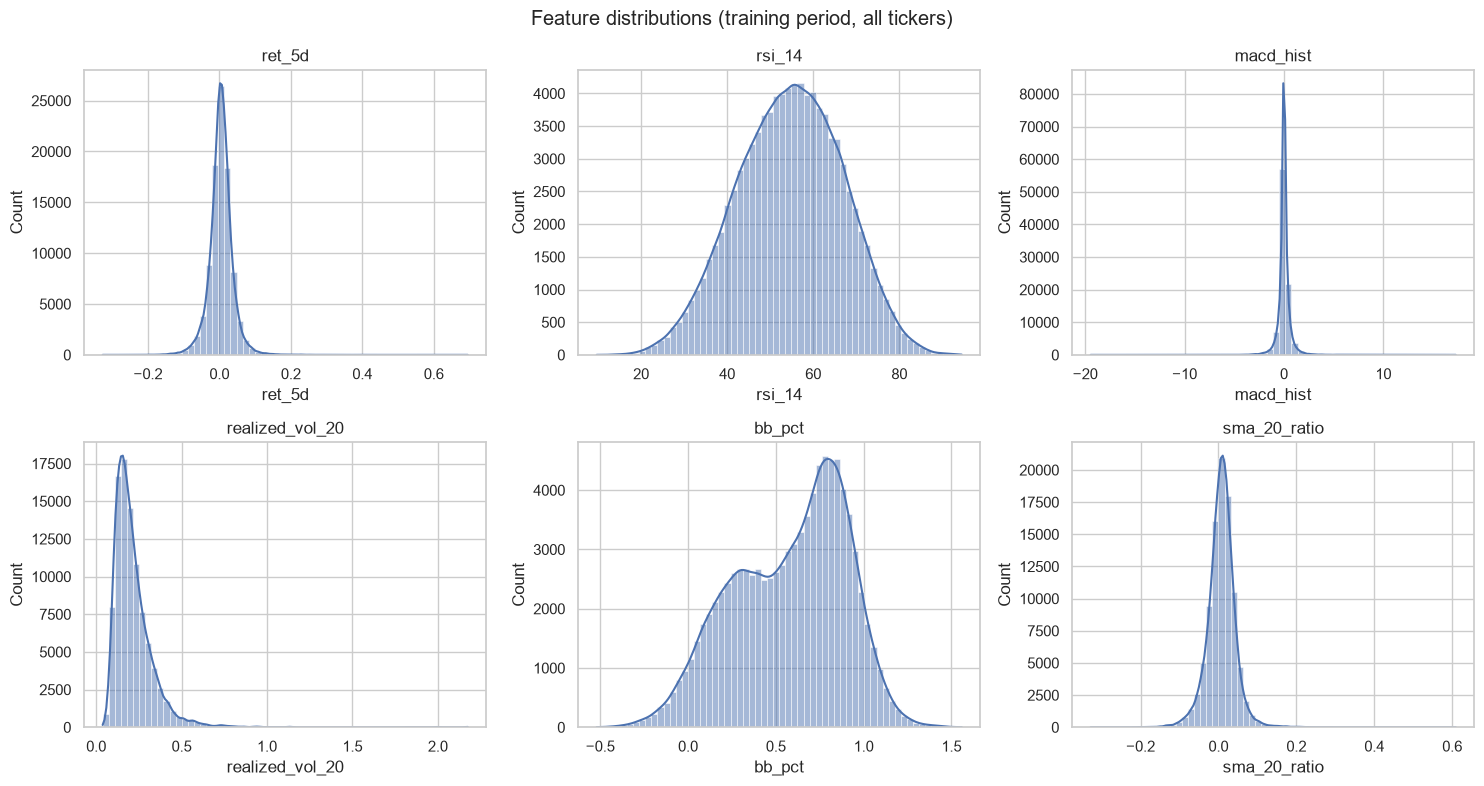

In [7]:
plot_cols = ["ret_5d", "rsi_14", "macd_hist", "realized_vol_20", "bb_pct", "sma_20_ratio"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(train_features[col], bins=60, ax=ax, kde=True)
    ax.set_title(col)
fig.suptitle("Feature distributions (training period, all tickers)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part1_feature_distributions.png", dpi=120)
plt.show()


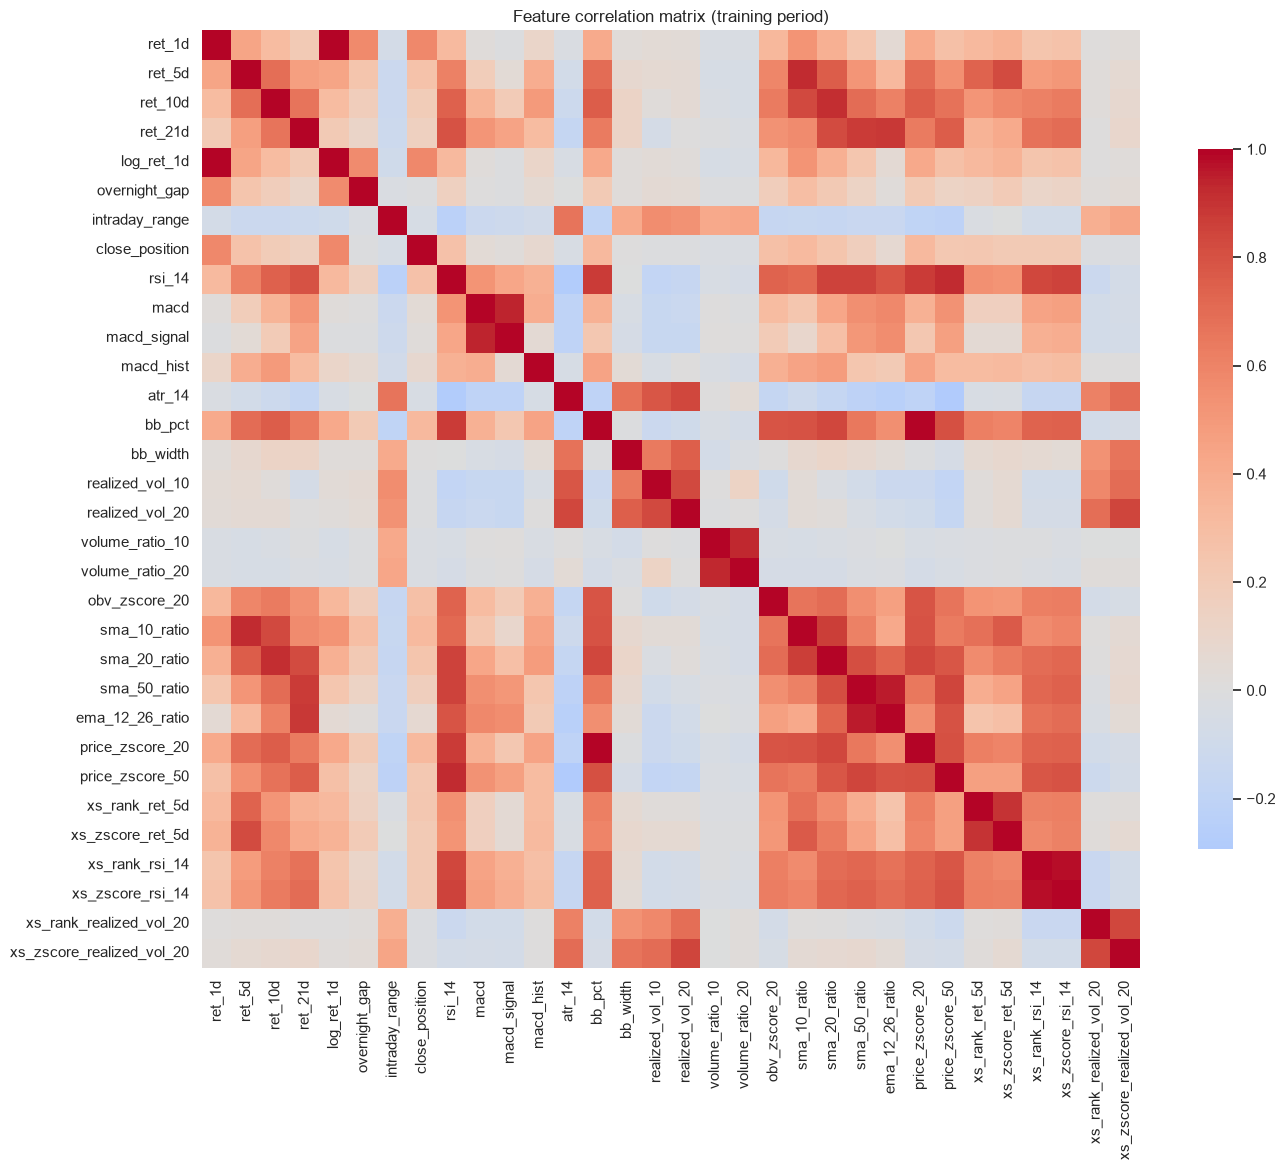

In [8]:
corr = train_features[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Feature correlation matrix (training period)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part1_feature_correlations.png", dpi=120)
plt.show()


### Information Coefficient (IC) sanity check

For each feature, compute the **daily cross-sectional Spearman correlation**
between that feature's value and the 5-day-forward return, averaged over
all training days (this is the same `cross_sectional_ic` / `ic_summary`
helper used to evaluate the model's score in Part 2). The goal here is just
a quick check that at least some hand-built features carry a small, noisy
signal before we bother building a model. Values of |mean IC| in roughly the
0.01-0.05 range are typical/expected for daily equity-like data; anything
dramatically larger on a single raw feature would be a red flag for a bug or
leakage.


In [9]:
ic_records = {}
for col in feature_cols:
    ic_series = cross_sectional_ic(train_eda, col, "fwd_return_eda")
    ic_records[col] = ic_summary(ic_series)

ic_df = pd.DataFrame(ic_records).T
ic_df = ic_df.sort_values("mean_ic", key=lambda s: s.abs(), ascending=False)
ic_df.to_csv(TABLES_DIR / "part1_feature_ic_train.csv")
ic_df.head(15)


,mean_ic,ic_std,ic_ir,hit_rate,n_days
atr_14,0.031875,0.237643,0.134128,0.561834,938.0
rsi_14,-0.027863,0.190590,-0.146194,0.450959,938.0
xs_zscore_rsi_14,-0.027863,0.190590,-0.146194,0.450959,938.0
xs_rank_rsi_14,-0.027863,0.190590,-0.146194,0.450959,938.0
ret_21d,-0.027582,0.191213,-0.144245,0.452026,938.0
ema_12_26_ratio,-0.027455,0.190542,-0.144089,0.459488,938.0
realized_vol_10,0.027367,0.197023,0.138904,0.561834,938.0
macd,-0.026901,0.169045,-0.159138,0.459488,938.0
sma_50_ratio,-0.026305,0.192843,-0.136407,0.449893,938.0
bb_pct,-0.025757,0.179230,-0.143710,0.459488,938.0


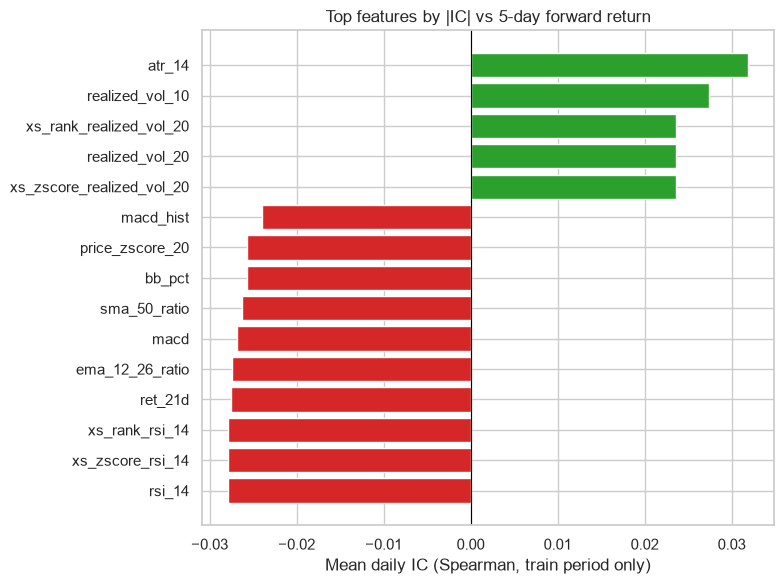

In [10]:
top_ic = ic_df.reindex(ic_df["mean_ic"].abs().sort_values(ascending=False).index).head(15)
plot_order = top_ic["mean_ic"].sort_values()
colors = ["tab:green" if v > 0 else "tab:red" for v in plot_order]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_order.index, plot_order.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Mean daily IC (Spearman, train period only)")
ax.set_title(f"Top features by |IC| vs {TARGET_HORIZON}-day forward return")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part1_feature_ic.png", dpi=120)
plt.show()


## 4. Save Processed Feature Table

The saved table contains only the engineered features, `close` (needed to
construct the target in Part 2), `date`, and `ticker`. No forward-return /
target columns are included, so Part 2 cannot accidentally train on a leaked
feature.


In [11]:
output_cols = ["date", "ticker", "close"] + feature_cols
features[output_cols].to_parquet(PROCESSED_DIR / "features.parquet", index=False)

with open(PROCESSED_DIR / "feature_columns.txt", "w") as f:
    f.write("\n".join(feature_cols))

print(f"Saved {len(features)} rows x {len(output_cols)} columns to "
      f"{PROCESSED_DIR / 'features.parquet'}")
print(f"Saved {len(feature_cols)} feature names to {PROCESSED_DIR / 'feature_columns.txt'}")

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "start": [TRAIN_START, VAL_START, TEST_START],
    "end": [TRAIN_END, VAL_END, TEST_END],
    "n_rows": [
        int(((features["date"] >= TRAIN_START) & (features["date"] <= TRAIN_END)).sum()),
        int(((features["date"] >= VAL_START) & (features["date"] <= VAL_END)).sum()),
        int(((features["date"] >= TEST_START) & (features["date"] <= TEST_END)).sum()),
    ],
})
split_summary.to_csv(TABLES_DIR / "part1_split_summary.csv", index=False)
split_summary


Saved 246199 rows x 35 columns to C:\Users\Anil Prajapati\Downloads\precog_resume\precog-quant-task\PRECOG\data\processed\features.parquet
Saved 32 feature names to C:\Users\Anil Prajapati\Downloads\precog_resume\precog-quant-task\PRECOG\data\processed\feature_columns.txt


,split,start,end,n_rows
0,train,2016-01-25,2019-12-31,94299
1,validation,2020-01-01,2021-12-31,50500
2,test,2022-01-01,2026-01-16,101400


## Summary

- Loaded 100 tickers x 2511 days of OHLCV data, validated it (no missing
  values, one shared trading calendar across all tickers), and fixed a
  handful of floating-point OHLC ordering violations.
- Flagged (but did not remove) the small fraction of daily returns that are
  extreme relative to each ticker's own trailing 252-day history.
- Engineered 32 causal features per (date, ticker): return, momentum,
  volatility, volume, trend, and price-location indicators, plus
  cross-sectional rank/z-score versions of three of them.
- Verified on the **training period only** (with an embargo on the
  forward-return window) that several features carry a small but non-zero
  IC against the 5-day forward return -- consistent with noisy-but-not-random
  financial data, and a useful baseline for the model in Part 2.
- Saved `data/processed/features.parquet` (features + close, no targets) for
  Part 2.

**Next**: `Part2_Model_Training_Strategy.ipynb` builds the walk-forward
ensemble model and evaluates it via IC across 2020-2026.
